**Objective:** Provide insights about customers' behavioural patterns and trends to improve comapny's sales and its marketing strategies.

In [208]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

In [209]:
cust_shopdata = pd.read_csv('customer_shopping_data.csv')
cust_shopdata.head(2)

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,8/05/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul


In [210]:
#Check data info before cleaning
cust_shopdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99461 entries, 0 to 99460
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99461 non-null  object 
 1   customer_id     99461 non-null  object 
 2   gender          99461 non-null  object 
 3   age             99461 non-null  int64  
 4   category        99461 non-null  object 
 5   quantity        99461 non-null  int64  
 6   price           99459 non-null  float64
 7   payment_method  99460 non-null  object 
 8   invoice_date    99461 non-null  object 
 9   shopping_mall   99461 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB


# **Data Cleaning**

I firstly checked the format of dates in this dataset as this proved to be the greatest obstacle in analysis and creating visualizations for our data.
I disovered that there are dates that were not correctly formatted into a proper date format. Instead of fixing these values, I chose to drop these since it will not have a significant impact in our analysis.

In [213]:
#Get date values that are not in a proper date format and get row location
incorrect_date_format = cust_shopdata[cust_shopdata['invoice_date'].str.contains('44')]
incorrect_date_format['invoice_date']

13       44882
30       44746
49       44360
112      44522
236      44761
249      44416
353      44761
53518    44576
53519    44222
53539    44534
53606    44938
76666    44513
76687    44575
76781    44336
99389    44787
99418    44597
Name: invoice_date, dtype: object

In [214]:
#Drop incorrectly formatted dates
drop_date_rows = [13, 30, 49, 112, 236, 249, 353, 53518, 53519, 53539, 53606, 76666, 76687, 76781, 99389, 99418]
cust_shopdata = cust_shopdata.drop(drop_date_rows)

## Remove Duplicates

As the note stated, invoice_no and customer_id are uniquely assigned per transaction, there shouldn't be any duplicate records of these.

In [217]:
#cust_shopdata = cust_shopdata.drop_duplicates(subset=['invoice_no'])
cust_shopdata = cust_shopdata.drop_duplicates(subset=['customer_id'])

In [218]:
cust_shopdata[cust_shopdata['category'] == 'Technology']

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
23,I252275,C313348,Male,44,Technology,5,5250.0,Cash,10/26/2021,Kanyon
53,I160777,C626042,Female,43,Technology,4,4200.0,Cash,2/22/2022,Metrocity
69,I883721,C236859,Female,44,Technology,5,5250.0,Credit Card,11/19/2021,Mall of Istanbul
90,I289643,C584700,Female,43,Technology,2,2100.0,Cash,8/22/2022,Kanyon
100,I283443,C189493,Male,43,Technology,3,3150.0,Credit Card,5/25/2022,Viaport Outlet
...,...,...,...,...,...,...,...,...,...,...
99392,I705676,C154530,Female,27,Technology,2,2100.0,Cash,12/06/2021,Metrocity
99402,I129245,C276524,Female,44,Technology,2,2100.0,Debit Card,5/28/2021,Forum Istanbul
99417,I120044,C327276,Female,24,Technology,1,1050.0,Debit Card,5/26/2021,Mall of Istanbul
99428,I549710,C541824,Female,34,Technology,3,3150.0,Cash,1/13/2021,Metrocity


## Null values

In [220]:
#Check all null values and assess one by one
cust_shopdata.isnull().sum()

invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             2
payment_method    1
invoice_date      0
shopping_mall     0
dtype: int64

### Null values: payment_method

In [222]:
cust_shopdata[cust_shopdata['payment_method'].isnull()]

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
298,I215906,C296862,Male,21,Clothing,4,1200.32,NaN,8/13/2021,Mall of Istanbul


In [223]:
#Check what options are available to replace the null value with
cust_shopdata['payment_method'].unique()

array(['Credit Card', 'Debit Card', 'Cash', nan], dtype=object)

Since there are a lot of erroneous entries in the payment method, we must fix it using *replace* function to make the entries consistent before we fill the missing value.

### Replace values: payment_method

<b>  </b>

In [227]:
# Replace values accordingly

corrections_payment = { 'nan' : np.nan, 'Cash Cash' : 'Cash', 'CreditCard' : 'Credit Card'}
cust_shopdata['payment_method'] = cust_shopdata['payment_method'].replace(corrections_payment)

# Check if there are any values that haven't been fixed
cust_shopdata['payment_method'].unique()

array(['Credit Card', 'Debit Card', 'Cash', nan], dtype=object)

In [228]:
# Check the most frequently used payment method
cust_shopdata['payment_method'].value_counts()

payment_method
Cash           44441
Credit Card    34927
Debit Card     20076
Name: count, dtype: int64

In [229]:
# Since Cash is the most frequently used payment method, we will use it to replace the payment method null values
cust_shopdata['payment_method'] = cust_shopdata['payment_method'].fillna('Cash')

Now that we have cleaned payment method column, lets proceed with price column

### Null values: price

In [232]:
# Check all the values according to missing value's row
cust_shopdata[cust_shopdata['price'].isnull()]

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
64,I218590,C224743,Female,29,Cosmetics,4,NaN,Debit Card,5/09/2022,Metropol AVM
419,I177957,C653357,Male,65,Clothing,4,NaN,Cash,7/04/2021,Cevahir AVM


It wouldn't make sense if we fill the missing values with the overall average, median or mode when there are different types of categories. It's better to fill the missing values with average according to their category.

In [234]:
# Fill missing values according to category's mean
category_mean = cust_shopdata.groupby('category')['price'].transform('mean')
cust_shopdata['price'] = cust_shopdata['price'].fillna(category_mean)

In [235]:
#check if missing values had been filled - cosmetics
cust_shopdata.iloc[[64]]

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
67,I204979,C173084,Female,24,Souvenir,5,58.65,Debit Card,3/14/2021,Istinye Park


In [236]:
#check if missing values had been filled - clothing
cust_shopdata.iloc[[419]]

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
426,I884439,C304835,Female,54,Toys,4,143.36,Credit Card,8/22/2022,Kanyon


In [237]:
# Check if there are any more missing values that haven't been filled

cust_shopdata.isnull().sum()

invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
dtype: int64

Now that all missing values have been cleaned, we continue cleaning the data categories by transforming the values to be more consistent using replace function.

### Replace values: gender

In [240]:
# Check gender data inconsistencies
cust_shopdata['gender'].unique()

array(['Female', 'Male'], dtype=object)

In [241]:
# Replace gender data accordingly
corrections_gender = {'Mal' : 'Male'}
cust_shopdata['gender'] = cust_shopdata['gender'].replace(corrections_gender)
cust_shopdata['gender'].unique()

array(['Female', 'Male'], dtype=object)

### Replace values: category

In [243]:
# Check category data inconsistencies
cust_shopdata['category'].unique()

array(['Clothing', 'Shoes', 'Books', 'Cosmetics', 'Food & Beverage',
       'Toys', 'Technology', 'Souvenir'], dtype=object)

In [244]:
# Replace category data accordingly
corrections_category = {'Clothi' : 'Clothing', 'Toy' : 'Toys', 'Boks' : 'Books', 'Shoe' : 'Shoes', 'Tech' : 'Technology', 'Cosmetic' : 'Cosmetics', 'Food' : 'Food & Beverage'}
cust_shopdata['category'] = cust_shopdata['category'].replace(corrections_category)
cust_shopdata['category'].unique()

array(['Clothing', 'Shoes', 'Books', 'Cosmetics', 'Food & Beverage',
       'Toys', 'Technology', 'Souvenir'], dtype=object)

### Replace values: shopping_mall

In [246]:
# Check shopping mall data inconsistencies
cust_shopdata['shopping_mall'].unique()

array(['Kanyon', 'Forum Istanbul', 'Metrocity', 'Metropol AVM',
       'Istinye Park', 'Mall of Istanbul', 'Emaar Square Mall',
       'Viaport Outlet', 'Zorlu Center', 'Cevahir AVM'], dtype=object)

In [247]:
# Replace shopping mall data accordingly

corrections_mall = {'Mall Istanbul' : 'Mall of Istanbul'}
cust_shopdata['shopping_mall'] = cust_shopdata['shopping_mall'].replace(corrections_mall)
cust_shopdata['shopping_mall'].unique()

array(['Kanyon', 'Forum Istanbul', 'Metrocity', 'Metropol AVM',
       'Istinye Park', 'Mall of Istanbul', 'Emaar Square Mall',
       'Viaport Outlet', 'Zorlu Center', 'Cevahir AVM'], dtype=object)

In [248]:
# Check data info after cleaning
cust_shopdata.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99445 entries, 0 to 99460
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99445 non-null  object 
 1   customer_id     99445 non-null  object 
 2   gender          99445 non-null  object 
 3   age             99445 non-null  int64  
 4   category        99445 non-null  object 
 5   quantity        99445 non-null  int64  
 6   price           99445 non-null  float64
 7   payment_method  99445 non-null  object 
 8   invoice_date    99445 non-null  object 
 9   shopping_mall   99445 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 8.3+ MB


To check the skewness of the price distribution, we create a visualization using the histogram. Instead of an overall price histogram, it would make more sense to check the price by category as each category has their own pricing strategy (e.g. Technology would be priced higher as opposed to Souvenirs). 

In [250]:
# Create a new dataframe for each category for histogram
cloth = cust_shopdata[cust_shopdata['category'] == 'Clothing']
shoes = cust_shopdata[cust_shopdata['category'] == 'Shoes']
books = cust_shopdata[cust_shopdata['category'] == 'Books']
cosm = cust_shopdata[cust_shopdata['category'] == 'Cosmetics']
food = cust_shopdata[cust_shopdata['category'] == 'Food & Beverage']
toys = cust_shopdata[cust_shopdata['category'] == 'Toys']
tech = cust_shopdata[cust_shopdata['category'] == 'Technology']
souv = cust_shopdata[cust_shopdata['category'] == 'Souvenir']

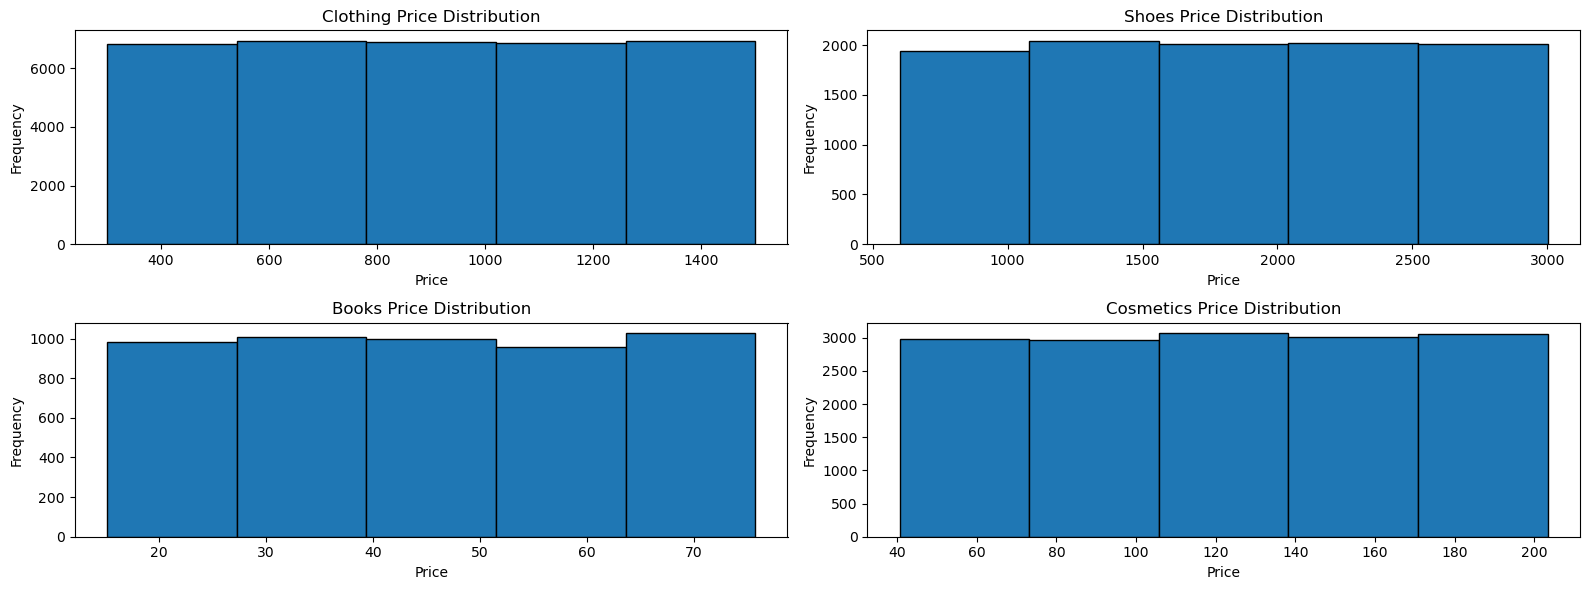

In [251]:
# show histogram for each category (1)
plt.figure(figsize = (16,6))

plt.subplot(2,2,1)
plt.hist(cloth['price'], bins=5, edgecolor='black')
plt.title('Clothing Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.subplot(2,2,2)
plt.hist(shoes['price'], bins=5, edgecolor='black')
plt.title('Shoes Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.subplot(2,2,3)
plt.hist(books['price'], bins=5, edgecolor='black')
plt.title('Books Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.subplot(2,2,4)
plt.hist(cosm['price'], bins=5, edgecolor='black')
plt.title('Cosmetics Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

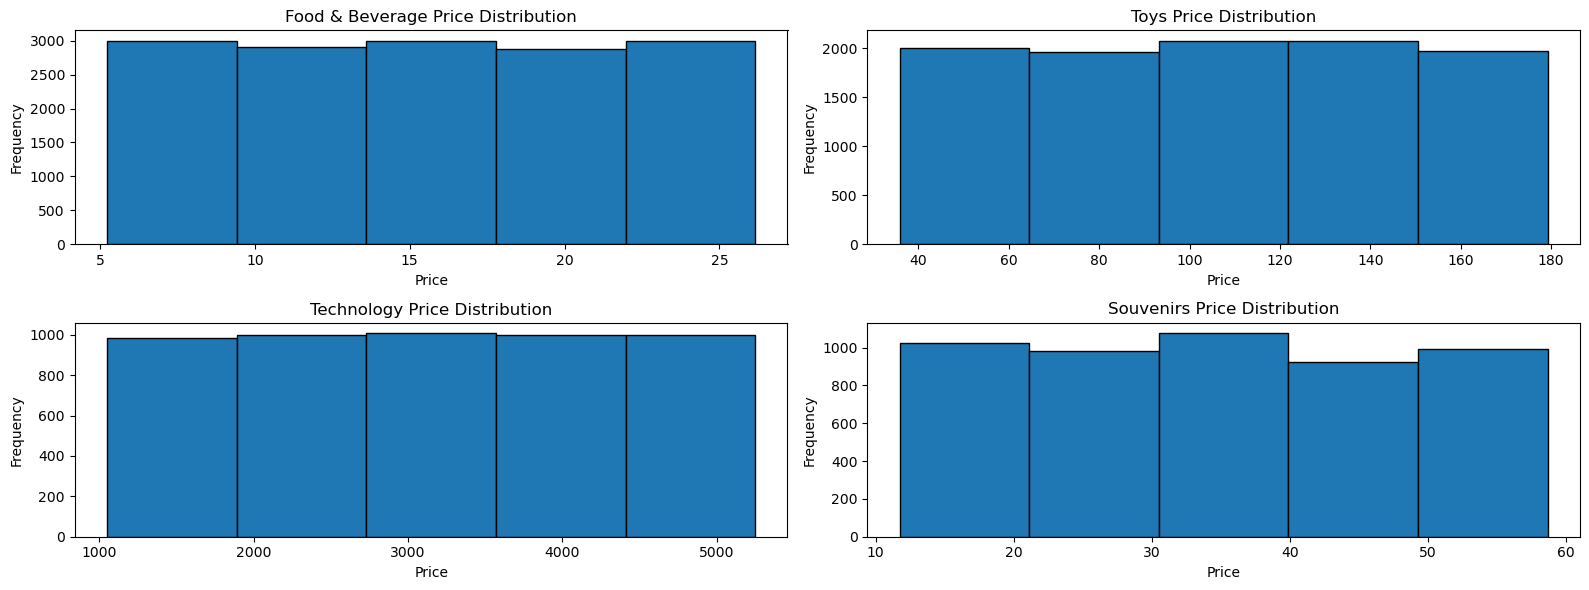

In [252]:
# show histogram for each category (2)
plt.figure(figsize = (16,6))

plt.subplot(2,2,1)
plt.hist(food['price'], bins=5, edgecolor='black')
plt.title('Food & Beverage Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.subplot(2,2,2)
plt.hist(toys['price'], bins=5, edgecolor='black')
plt.title('Toys Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.subplot(2,2,3)
plt.hist(tech['price'], bins=5, edgecolor='black')
plt.title('Technology Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.subplot(2,2,4)
plt.hist(souv['price'], bins=5, edgecolor='black')
plt.title('Souvenirs Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

No skewness have been found in the pricing distribution for all the categories. This suggests that the pricing for each category had been uniform, no significantly high or low prices. To further check the skewness, we can use the *skew()* function to decide further strengthen the idea if we need to transform the data or not.

In [254]:
print("Price Skewness of the following Categories:")
print("Clothing:", cloth['price'].skew())
print("Shoes:", shoes['price'].skew())
print("Books:", books['price'].skew())
print("Cosmetics:", cosm['price'].skew())
print("Food & Beverage:", food['price'].skew())
print("Toys:", toys['price'].skew())
print("Technology:", tech['price'].skew())
print("Souvenirs:", souv['price'].skew())

Price Skewness of the following Categories:
Clothing: 0.001123032866792554
Shoes: -0.005537203817008163
Books: 0.0050427115886719
Cosmetics: -0.010459191459225968
Food & Beverage: 0.004339485021885479
Toys: -0.01677607858079345
Technology: -0.0051333365436294544
Souvenirs: 0.030970405173599357


As the price skewness for each category is neither less than -1 nor greather than 1 (close to zero), this indicates that our price distribution is not highly skewed. Thus, no data transformatio needed.

Now that we have thoroughly cleaned the data, we can now check data outliers.

## **Outliers**

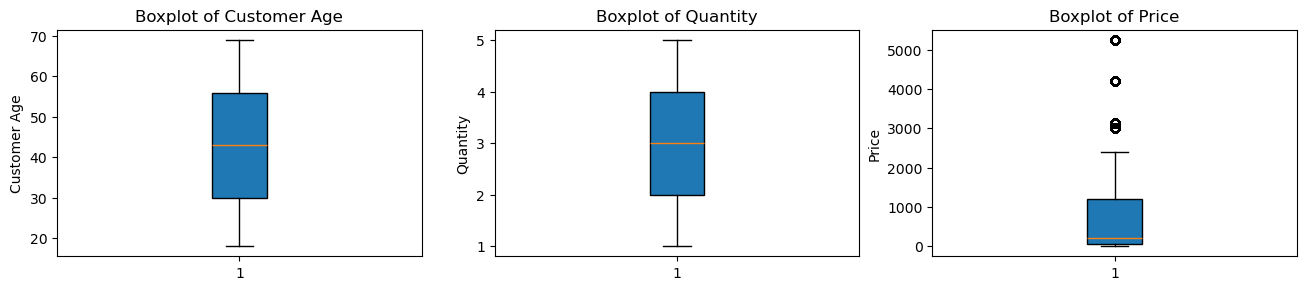

In [257]:
plt.figure(figsize=(16, 10))

# Age
plt.subplot(3, 3, 1)
plt.boxplot(cust_shopdata['age'], patch_artist=True)
plt.title('Boxplot of Customer Age')
plt.ylabel('Customer Age')

# Quantity
plt.subplot(3, 3, 2)
plt.boxplot(cust_shopdata['quantity'], patch_artist=True)
plt.title('Boxplot of Quantity')
plt.ylabel('Quantity')

#Price
plt.subplot(3, 3, 3)
plt.boxplot(cust_shopdata['price'], patch_artist=True)
plt.title('Boxplot of Price')
plt.ylabel('Price')

plt.show()

Similar to checking the pricing skewness, we will check the outliers per category but per our histogram, it would be unlikely for us to find an outlier.

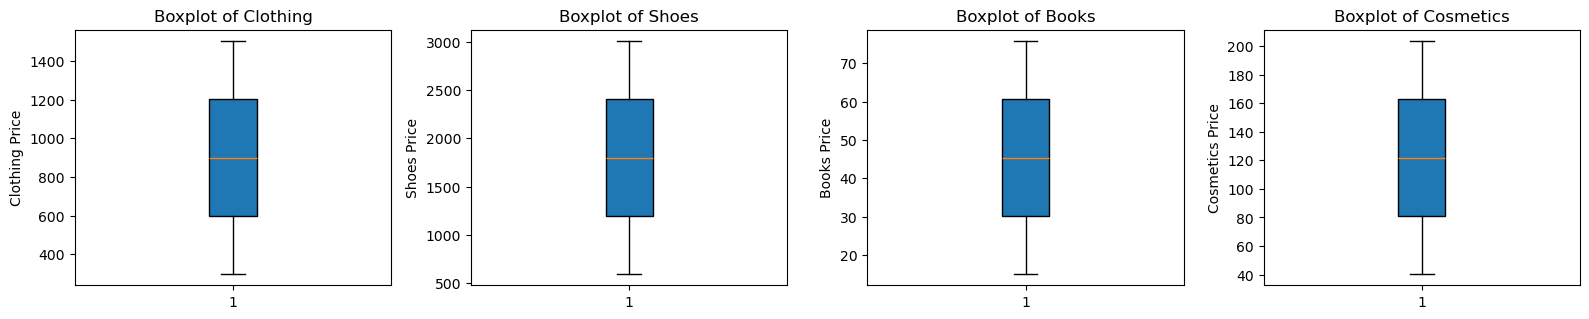

In [259]:
# show boxplot for each category (1)
plt.figure(figsize = (16,6))

plt.subplot(2,4,1)
plt.boxplot(cloth['price'], patch_artist=True)
plt.title('Boxplot of Clothing')
plt.ylabel('Clothing Price')

plt.subplot(2,4,2)
plt.boxplot(shoes['price'], patch_artist=True)
plt.title('Boxplot of Shoes')
plt.ylabel('Shoes Price')

plt.subplot(2,4,3)
plt.boxplot(books['price'], patch_artist=True)
plt.title('Boxplot of Books')
plt.ylabel('Books Price')

plt.subplot(2,4,4)
plt.boxplot(cosm['price'], patch_artist=True)
plt.title('Boxplot of Cosmetics')
plt.ylabel('Cosmetics Price')

plt.tight_layout()
plt.show()


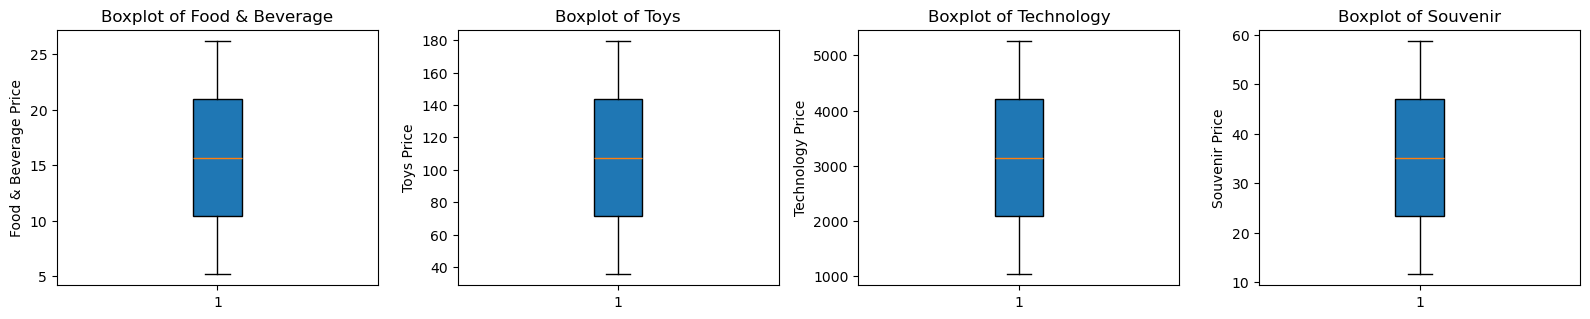

In [260]:
# show boxplot for each category (2)

plt.figure(figsize = (16,6))

plt.subplot(2,4,1)
plt.boxplot(food['price'], patch_artist=True)
plt.title('Boxplot of Food & Beverage')
plt.ylabel('Food & Beverage Price')

plt.subplot(2,4,2)
plt.boxplot(toys['price'], patch_artist=True)
plt.title('Boxplot of Toys')
plt.ylabel('Toys Price')

plt.subplot(2,4,3)
plt.boxplot(tech['price'], patch_artist=True)
plt.title('Boxplot of Technology')
plt.ylabel('Technology Price')

plt.subplot(2,4,4)
plt.boxplot(souv['price'], patch_artist=True)
plt.title('Boxplot of Souvenir')
plt.ylabel('Souvenir Price')

plt.tight_layout()
plt.show()


No outliers found for each cateegory's price.

# **Analysis**

### Based on your analysis, which customer segments/categories should the shopping mall target for marketing campaigns?

In [264]:
# Total the number of quantity sold per category and sort the values from highest to lowest for better visualization
category_quantity = cust_shopdata.groupby('category')['quantity'].sum()
category_quantity = category_quantity.sort_values(ascending=False)

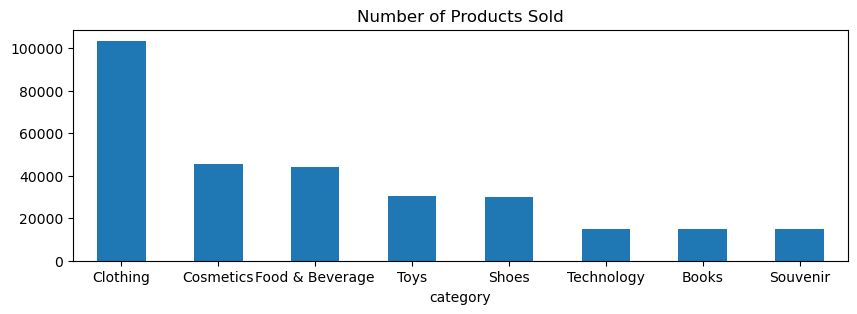

In [265]:
# Visuaalize the data
plt.]=[figure(figsize = (10,3))
category_quantity.plot(kind = 'bar')
plt.xticks(rotation=0)
plt.title('Number of Products Sold')

plt.show()

In [266]:
# Add Sales column
cust_shopdata['Sales'] = cust_shopdata['quantity'] * cust_shopdata['price']
cust_shopdata.head(2)

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,Sales
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,8/05/2022,Kanyon,7502.00
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul,5401.53


In [267]:
# Total the sales per category and sort the values from highest to lowest for better visualization
category_sales = cust_shopdata.groupby('category')['Sales'].sum()
category_sales = category_sales .sort_values(ascending=False)
category_sales

category
Clothing           1.139944e+08
Shoes              6.654805e+07
Technology         5.786130e+07
Cosmetics          6.791320e+06
Toys               3.979459e+06
Food & Beverage    8.493572e+05
Books              8.340378e+05
Souvenir           6.358247e+05
Name: Sales, dtype: float64

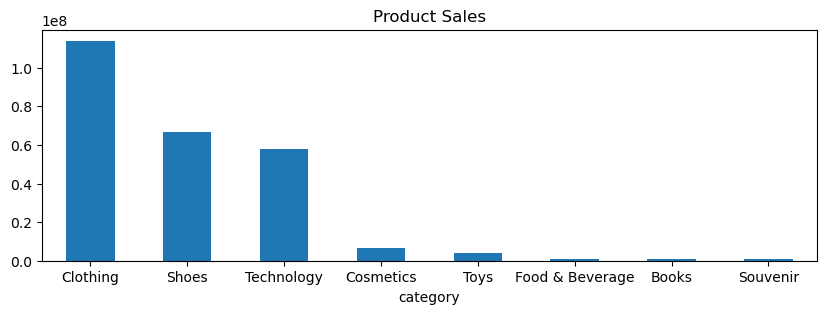

In [268]:
# Visuaalize the data
plt.figure(figsize = (10,3))
category_sales.plot(kind = 'bar')
plt.xticks(rotation=0)
plt.title('Product Sales')

plt.show()

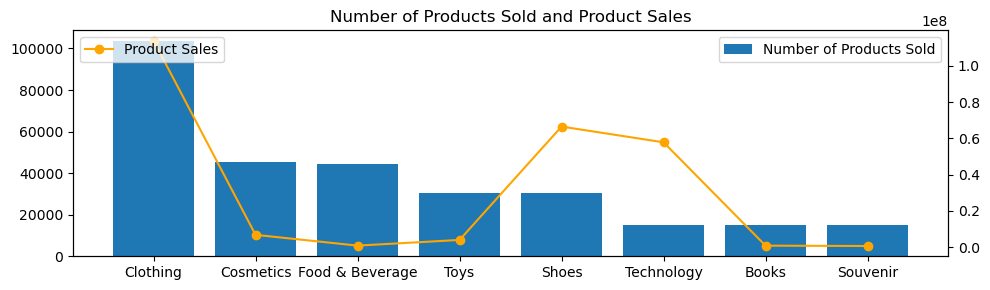

In [269]:
# For better analysis, combine the number of quantity sold and sales
fig, bar_quantity= plt.subplots(figsize=(10, 3))

# Create the Number of Products Sold chart
bar_quantity.bar(category_quantity.index, category_quantity, label='Number of Products Sold')

# Create a new variable for Product Sales to combine with Number of Products Sold
line_sales = bar_quantity.twinx()

# Visualize the Number of Products Sold and Product Sales
line_sales.plot(category_sales[category_quantity.index].index, category_sales[category_quantity.index], color='orange', marker='o', linestyle='-', label='Product Sales')
plt.title('Number of Products Sold and Product Sales')
bar_quantity.legend(loc = 'upper right')
line_sales.legend(loc = 'upper left')

plt.tight_layout()
plt.show()

#### Analysis 1: 

Based on the combo chart, Clothing is the highest selling product and has the highest sales. Books and Souvenirs had the lowest number of products sold hence, the lowest sales. Although the quantities sold quantity sold for Shoes and Technology, both had more sales compared to Cosmetics, Food & Beverage and Toys despite having more quantities sold. Lastly, Food & Beverage is third to our highest selling product but sales is almost on par with Books and Souevenir.

### Create a scatter plot to visualise the relationship between age and spending. What insights can you derive from this visualization? Is there a correlation between age and spending?

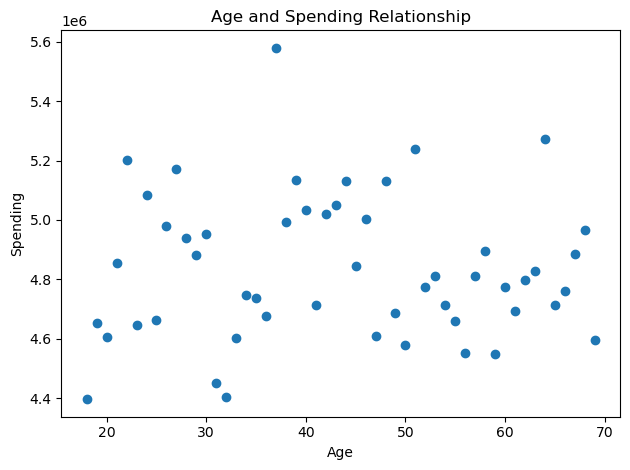

In [272]:
# Total the Sales per Age
age_spending = cust_shopdata.groupby('age')['Sales'].sum().reset_index()

# Visualize the data
plt.scatter(age_spending['age'], age_spending['Sales'])
plt.title("Age and Spending Relationship")
plt.xlabel("Age")
plt.ylabel("Spending")
plt.tight_layout()
plt.show()


### Analysis 2:
As shown in the scatterplot, it seems that age has no relevance when it comes to spending. Spending behaviour is consistent regardless of the age. No pattern and no correlation found between the two variables.


### Create a box plot to compare the distribution of spending scores between male and female customers. What can you infer from the box plot about the spending behaviour of different genders?

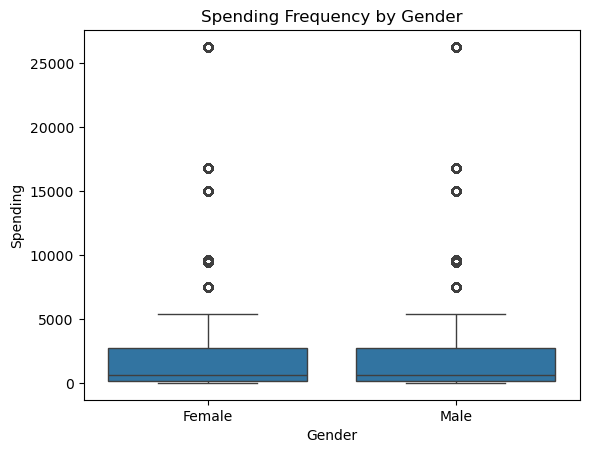

In [275]:
# Visualize the data

sns.boxplot(x = cust_shopdata['gender'], y = cust_shopdata['Sales'])
plt.title('Spending Frequency by Gender')
plt.xlabel('Gender')
plt.ylabel('Spending')

plt.show()

### Analysis 3:
Spending patterns between both genders are similar including outliers. Spending scores seems to be consistent in both genders.

### Segment the customers into different age groups (e.g., 18-25, 26-35, 36-45, 46-55, 56+). How does the spending score vary across these age groups? Provide a visualisation to support your analysis.


In [278]:
# Group the ages
bins = [0, 25, 35, 45, 55, 100]
age_group = ['18-24', '26-35', '36-45','46-55', '56+']

# Add Age Group column
cust_shopdata['Age Group'] = pd.cut(cust_shopdata['age'], bins=bins, labels = age_group, right = True)

# Check if the column has been added
cust_shopdata.head(2)

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,Sales,Age Group
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,8/05/2022,Kanyon,7502.00,26-35
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul,5401.53,18-24


In [ ]:
# Total the age group count
age_group_count = cust_shopdata['Age Group'].value_counts()

# Total the age group's spending
age_group_spending = cust_shopdata.groupby('Age Group')['Sales'].sum()

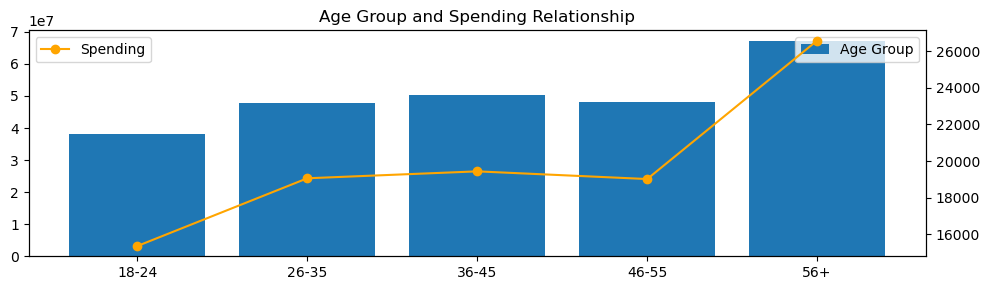

In [280]:
# Visualize the data

# Create the Age Group Count
fig, bar_spending = plt.subplots(figsize=(10,3))
bar_spending.bar(age_group_spending.index, age_group_spending, label='Age Group')

# Create a new variable for Age Group Spending to combine with Age Group Count
line_age = bar_spending.twinx()

# Visualize the Age Group Spending
line_age.plot(age_group_count[age_group_spending.index].index, age_group_count[age_group_spending.index], color='orange', marker='o', linestyle='-', label='Spending')
plt.title('Age Group and Spending Relationship')
bar_spending.legend(loc = 'upper right')
line_age.legend(loc = 'upper left')


plt.tight_layout()
plt.show()

### Analysis 4: 
As we had segmented the age groups, new information had been uncovered compared to scatterplot of each age and spending. In the segmented age group, spending score increases as the age increases. Highest age group distribution and spending score observed in age group 56+ and lowest in 18-24.

## Create a visualisation to visualize the proportion of total sales made by each payment_method. What can you infer from this visualisation about customer preferences for payment methods?

In [283]:
payment_method_sales = cust_shopdata.groupby('payment_method')['Sales'].sum()

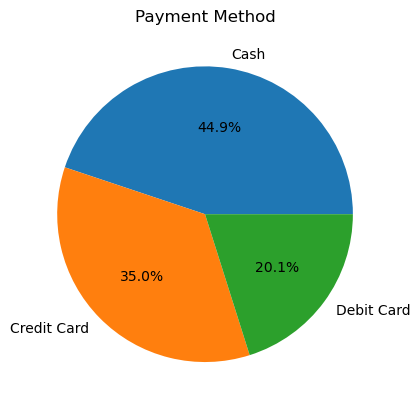

In [284]:
plt.pie(payment_method_sales, labels=payment_method_sales.index, autopct='%1.1f%%')
plt.title('Payment Method')
plt.show()

### Analysis 5: 
Majority of the payment method used by the consumers is Cash followed by Credit Card then Debit Card. 

## Create a line chart to visualize the total monthly sales over the period covered by the dataset. Provide insights into any trends or patterns you observe.

In [287]:
cust_shopdata['Date'] = pd.to_datetime(cust_shopdata['invoice_date'], format='mixed')

In [288]:
cust_shopdata['Year']= cust_shopdata['Date'].dt.year
cust_shopdata['Month']= cust_shopdata['Date'].dt.month
cust_shopdata.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,Sales,Age Group,Date,Year,Month
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,8/05/2022,Kanyon,7502.00,26-35,2022-08-05,2022,8
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul,5401.53,18-24,2021-12-12,2021,12
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,11/09/2021,Metrocity,300.08,18-24,2021-11-09,2021,11
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,5/16/2021,Metropol AVM,15004.25,56+,2021-05-16,2021,5
4,I337046,C189076,Female,53,Books,4,60.60,Cash,10/24/2021,Kanyon,242.40,46-55,2021-10-24,2021,10


In [289]:
#Total the sales per month and convert the months' number to month name for better visualization

#2021
plt.figure(figsize = (10,5))
year_2021 = cust_shopdata[cust_shopdata['Year'] == 2021]
sales_2021 = year_2021.groupby('Month')['Sales'].sum()
months2021 = pd.to_datetime(sales_2021.index, format='%m').strftime('%B')

#2022
plt.figure(figsize = (10,5))
year_2022 = cust_shopdata[cust_shopdata['Year'] == 2022]
sales_2022 = year_2022.groupby('Month')['Sales'].sum()
months2022 = pd.to_datetime(sales_2022.index, format='%m').strftime('%B')

#2023
year_2023 = cust_shopdata[cust_shopdata['Year'] == 2023]
sales_2023 = year_2023.groupby('Month')['Sales'].sum()
months2023 = pd.to_datetime(sales_2023.index, format='%m').strftime('%B')

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

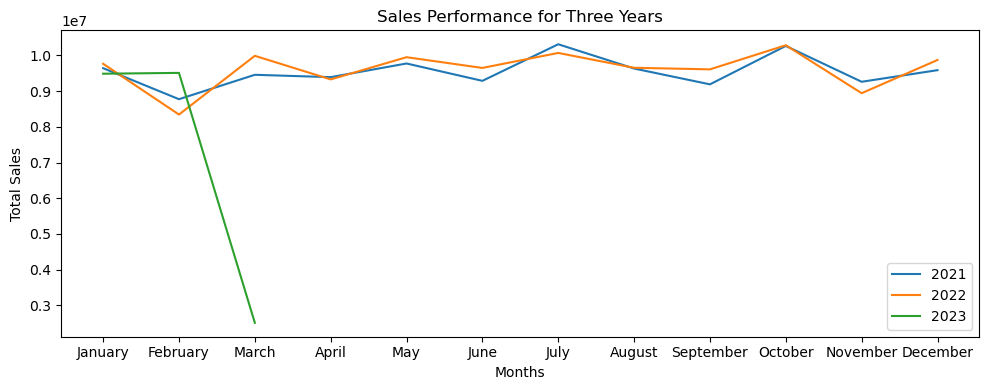

In [290]:
#Create the line chart to show the sales performance for 3 years throughout the months.

plt.figure(figsize = (10,4))
plt.plot(months2021, sales_2021, label = '2021')
plt.plot(months2022, sales_2022, label = '2022')
plt.plot(months2023, sales_2023, label = '2023')

plt.title ("Sales Performance for Three Years")
plt.ylabel ("Total Sales")
plt.xlabel ("Months")
plt.legend(loc = 'lower right')

plt.tight_layout()
plt.show()

In [291]:
#March Sales performances is very low. Check the dates in march if its complete until end of month.
March2023 = year_2023[year_2023['Month'] == 3]
March2023['Date'].unique().tolist()

[Timestamp('2023-03-07 00:00:00'),
 Timestamp('2023-03-08 00:00:00'),
 Timestamp('2023-03-05 00:00:00'),
 Timestamp('2023-03-02 00:00:00'),
 Timestamp('2023-03-04 00:00:00'),
 Timestamp('2023-03-03 00:00:00'),
 Timestamp('2023-03-06 00:00:00'),
 Timestamp('2023-03-01 00:00:00')]

### Analysis 6:
Sales performance of 2021 and 2022 had been consistent with each other throughout the months. As for 2023, January sales was slightly lower compared to the past two years but had a noticeable increase in February. As the data for March 2023 isn't complete, its understandable that total sales for this month is very low. It seems the report was requested to see end of month sales performance for February 2023 not until March 2023.

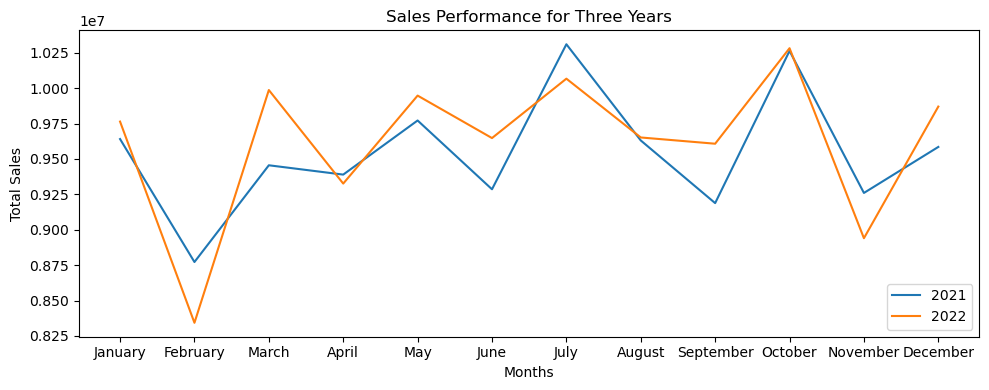

In [293]:
#Create the line chart to show the sales performance for 3 years throughout the months.

plt.figure(figsize = (10,4))
plt.plot(months2021, sales_2021, label = '2021')
plt.plot(months2022, sales_2022, label = '2022')

plt.title ("Sales Performance for Three Years")
plt.ylabel ("Total Sales")
plt.xlabel ("Months")
plt.legend(loc = 'lower right')

plt.tight_layout()
plt.show()

### Analysis 6.1

As 2021 and 2022 sales had been consistent with each other, it is observed that both had their lowest sales in February. Almost similar sales performance in October, peak for 2022 but 2021 had its peak in July. 

## **Recommendation**

As we have seen the sales fluctuation, first thing we can focus on are the months with low sales. Putting on more promotional campaigns on our best-selling categories such as Clothing, Shoes and Technology would attract more customers during these low periods. We have seen that the 2023 February’s sales performance, the strategies implemented for this month can either be mimicked or improved for the other months.  

Technology and Shoes generates more sales despite having fewer units sold. Targeted marketing for ages 26-45 is best suited for these categories. These ages are more likely to keep up on the trend with regards to the collection of shoes, phones they are using, and home appliances with technology such as Smart TV, Smart Refrigerator etc.

Credit card usage can also be increased by offering payment terms or discounts that will generate more sales and revenue for the company. This would encourage customers to buy more since there will be savings on their purchases.  

Preparing marketing campaigns in advance and keeping up with the trend is essential to attract customers. Monitoring of monthly sales should be done to keep track of targets. Adjustments on the marketing strategies can be implemented when necessary. 